<a href="https://colab.research.google.com/github/Comfy05/Football_analytics_portfolio/blob/main/football_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install mplsoccer
!pip install statsbombpy

In [ ]:
import pandas as pd
from statsbombpy import sb
from mplsoccer import Pitch, VerticalPitch
from matplotlib.pyplot import scatter
import matplotlib.pyplot as plt

competitions = sb.competitions()
competitions.head(20)

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,None,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
5,16,2,Europe,Champions League,male,False,False,2016/2017,2024-02-13T02:37:32.205154,2021-06-13T16:17:31.694,None,2024-02-13T02:37:32.205154
6,16,27,Europe,Champions League,male,False,False,2015/2016,2024-06-12T07:45:38.786894,2021-06-13T16:17:31.694,None,2024-06-12T07:45:38.786894
7,16,26,Europe,Champions League,male,False,False,2014/2015,2024-02-12T12:49:54.914228,2021-06-13T16:17:31.694,None,2024-02-12T12:49:54.914228
8,16,25,Europe,Champions League,male,False,False,2013/2014,2024-02-12T12:48:48.479157,2021-06-13T16:17:31.694,None,2024-02-12T12:48:48.479157
9,16,24,Europe,Champions League,male,False,False,2012/2013,2024-02-12T12:47:34.340413,2021-06-13T16:17:31.694,None,2024-02-12T12:47:34.340413


In [ ]:
competiotions_WC2018 = competitions['competition_name'] == 'FIFA World Cup'
competiotions_WC2018 = competitions[competiotions_WC2018]
competiotions_WC2018.head()
#competition_id 43 dla WC2018
#season_id 3 dla WC2018

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
30,43,106,International,FIFA World Cup,male,False,True,2022,2026-05-04T01:48:57.914346,2026-05-04T01:53:40.309717,2026-05-04T01:53:40.309717,2026-05-04T01:48:57.914346
31,43,3,International,FIFA World Cup,male,False,True,2018,2026-05-15T15:48:12.789440,2021-06-13T16:17:31.694,None,2026-05-15T15:48:12.789440
32,43,55,International,FIFA World Cup,male,False,True,1990,2023-06-28T10:58:20.137929,2021-06-12T16:17:31.694,None,2023-06-28T10:58:20.137929
33,43,54,International,FIFA World Cup,male,False,True,1986,2026-05-04T01:30:23.212111,2021-06-13T16:17:31.694,None,2026-05-04T01:30:23.212111
34,43,51,International,FIFA World Cup,male,False,True,1974,2026-05-15T02:20:43.439689,2021-06-13T16:17:31.694,None,2026-05-15T02:20:43.439689


In [ ]:
competitions.columns

Index(['competition_id', 'season_id', 'country_name', 'competition_name',
       'competition_gender', 'competition_youth', 'competition_international',
       'season_name', 'match_updated', 'match_updated_360',
       'match_available_360', 'match_available'],
      dtype='object')

In [ ]:
matches = sb.matches(competition_id=43, season_id=3)
matches.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,8650,2018-07-06,18:00:00.000,1,2,available,scheduled,2026-05-15T15:44:36.027327,2021-06-13T16:17:31.694,5,...,Brazil,263,Roberto Martínez Montoliú,Roberto Martínez,1973-07-13,214,Spain,1.0.2,None,None
1,7584,2018-07-02,18:00:00.000,3,2,available,scheduled,2026-05-15T15:42:46.319084,2021-06-13T16:17:31.694,4,...,Spain,644,Akira Nishino,None,1955-04-07,114,Japan,1.0.2,None,None
2,7554,2018-06-24,12:00:00.000,6,1,available,scheduled,2026-05-15T15:40:36.254491,2021-06-13T16:17:31.694,2,...,England,654,Hernán Darío Gómez Jaramillo,Hernán Darío Gómez,1956-02-03,49,Colombia,1.0.2,None,None
3,7539,2018-06-19,15:00:00.000,1,2,available,scheduled,2026-05-15T15:39:59.042458,2021-06-13T16:17:31.694,1,...,Poland,635,Aliou Cissé,None,1976-03-24,202,Senegal,1.0.2,None,None
4,7550,2018-06-22,18:00:00.000,1,2,available,scheduled,2026-05-15T15:38:23.546532,2021-06-13T16:17:31.694,2,...,Serbia,492,Vladimir Petković,None,1963-08-15,28,Bosnia and Herzegovina,1.0.2,None,None


In [ ]:
france = matches['home_manager_country_name'] == 'France'
matches = matches[france]
matches.head(10)

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
9,7546,2018-06-21,15:00:00.000,1,0,available,scheduled,2026-05-15T15:37:28.413488,2021-06-13T16:17:31.694,2,...,France,629,Ricardo Alberto Gareca Nardi,Ricardo Gareca,1958-02-10,11,Argentina,1.0.2,None,None
31,7580,2018-06-30,14:00:00.000,4,3,available,scheduled,2026-05-15T15:39:23.000744,2021-06-13T16:17:31.694,4,...,France,637,Jorge Luis Sampaoli Moya,Jorge Sampaoli,1960-03-13,11,Argentina,1.0.2,None,None
38,7530,2018-06-16,10:00:00.000,2,1,available,scheduled,2026-05-15T15:33:59.845925,2021-06-13T16:17:31.694,1,...,France,630,Lambertus van Marwijk,None,1952-05-19,160,Netherlands,1.0.2,None,None
44,8658,2018-07-15,17:00:00.000,4,2,available,scheduled,2024-02-12T12:31:56.821876,2021-06-13T16:17:31.694,7,...,France,307,Zlatko Dalić,None,1966-10-26,56,Croatia,1.0.2,None,None
52,7577,2018-06-15,15:00:00.000,0,1,available,scheduled,2026-05-15T15:37:37.344535,2021-06-13T16:17:31.694,1,...,France,645,Carlos Manuel Brito Leal Queiróz,Carlos Queiroz,1953-03-01,183,Portugal,1.0.2,None,None
58,8655,2018-07-10,18:00:00.000,1,0,available,scheduled,2026-05-15T15:48:12.789440,2021-06-13T16:17:31.694,6,...,France,263,Roberto Martínez Montoliú,Roberto Martínez,1973-07-13,214,Spain,1.0.2,None,None


In [ ]:
#match_id = 8658
event = sb.events(match_id=8658)
event.columns

#strzały
shots = event['type'] == 'Shot'
event_shots = event[shots][['player','location','team','minute', 'shot_outcome']]

#zmiana lokalizacji na x y
event_shots = event_shots.join(pd.DataFrame(event_shots.pop('location').tolist(), index = event_shots.index, columns=["x", 'y']))
event_shots


,player,team,minute,shot_outcome,x,y
2906,Domagoj Vida,Croatia,20,Off T,112.0,49.0
2907,Ivan Rakitić,Croatia,23,Off T,108.0,29.0
2908,Ivan Perišić,Croatia,27,Goal,105.0,32.0
2909,Antoine Griezmann,France,37,Goal,108.0,40.0
2910,Ante Rebić,Croatia,39,Wayward,108.0,41.0
2911,Ivan Perišić,Croatia,42,Blocked,117.0,34.0
2912,Dejan Lovren,Croatia,42,Blocked,113.0,26.0
2913,Domagoj Vida,Croatia,45,Off T,115.0,40.0
2914,Antoine Griezmann,France,46,Saved,95.0,45.0
2915,Ante Rebić,Croatia,47,Saved,108.0,26.0


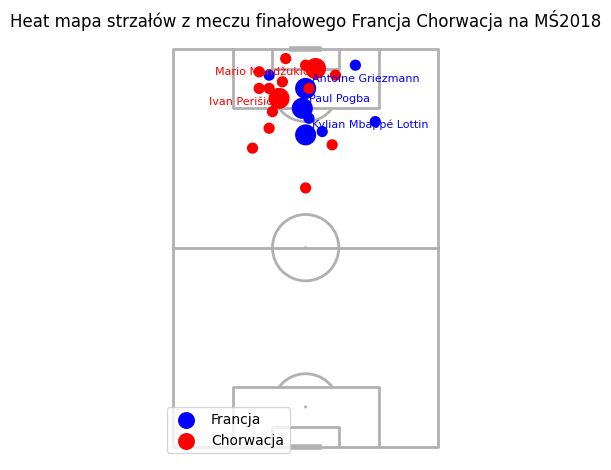

In [ ]:
croatia = event_shots["team"] == "Croatia"
france = event_shots["team"] == "France"
event_shots_croatia = event_shots[croatia]
event_shots_france = event_shots[france]

pitch = VerticalPitch(pitch_type="statsbomb")
fig, ax = pitch.draw()
ax.figsize()

pitch.scatter(event_shots_france['x'], event_shots_france['y'], ax=ax, color = 'blue', s=event_shots_france['shot_outcome'].apply(lambda x: 200 if x== 'Goal' else 50), label = 'Francja')
pitch.scatter(event_shots_croatia['x'], event_shots_croatia['y'], ax=ax, color = 'red', s=event_shots_croatia['shot_outcome'].apply(lambda x: 200 if x== 'Goal' else 50), label = 'Chorwacja')

for index, row in event_shots_france.iterrows():
    if row['shot_outcome'] == 'Goal':
        pitch.annotate(row['player'], (row['x'], row['y']), xytext=(row['x'] + 2, row['y'] + 2), textcoords='data', fontsize=8, color='blue', ax=ax)

for index, row in event_shots_croatia.iterrows():
    if row['shot_outcome'] == 'Goal':
        pitch.annotate(row['player'], (row['x'], row['y']), xytext=(row['x'] - 2, row['y'] - 2), textcoords='data', fontsize=8, color='red', ha='right', ax=ax)

ax.set_title('Mapa strzałów z meczu finałowego Francja Chorwacja na MŚ2018\n')
ax.legend(loc='lower left')
plt.savefig('map_of_shots.pdf')